# What is the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

## Import Libraries and Data
Import the libraries, data and change the job_posted_date to a datetime type.

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Data - only data for 2023
#dataset = load_dataset('lukebarousse/data_jobs')
#df = dataset['train'].to_pandas()

# Loading Data - 2023, 2024, 2025 and first half of 2026:

df = pd.read_csv(r"C:\Users\Nikola S\Desktop\Luke B\job_postings_flat.csv")

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## Clean Data
Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame df_DA_US. Drop NaN values from the 'salary_year_avg' column

In [4]:
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

df_DA_US = df_DA_US.dropna(subset="salary_year_avg")

df_DA_US_exploded = df_DA_US.explode("job_skills")

df_DA_US_exploded[["salary_year_avg", "job_skills"]].head(5)

,salary_year_avg,job_skills
218,55000.0,sql
218,55000.0,python
218,55000.0,numpy
218,55000.0,pandas
218,55000.0,seaborn


## Calculate Percent of Job Postings that Have Skills

In [7]:
df_DA_skills = df_DA_US_exploded.groupby("job_skills")["salary_year_avg"].agg(["count","median"]).sort_values(by="count", ascending=False)
df_DA_skills = df_DA_skills.rename(columns = {"count" : "skill_count", "median" : "median_salary"})

df_job_count = len(df_DA_US)

df_DA_skills["skill_perc"] = df_DA_skills["skill_count"] / df_job_count * 100

skill_perc_limit = 4.5


df_DA_skills_high_demand = df_DA_skills[df_DA_skills["skill_perc"] > skill_perc_limit]


df_DA_skills_high_demand

,skill_count,median_salary,skill_perc
job_skills,,,
sql,10704,97086.5000,44.918170
excel,8950,86009.5125,37.557700
python,7029,100000.0000,29.496433
tableau,6025,95000.0000,25.283256
power bi,4858,95000.0000,20.386068
r,3888,97193.2500,16.315569
sas,3382,95000.0000,14.192195
powerpoint,1740,85687.5000,7.301721
word,1635,79500.0000,6.861099


## Median Salary vs Percent Skill Demand
Create a scatter plot to visualize the relationship between the percentage of Data Analyst jobs that require specific skills and the median salary for those skills.

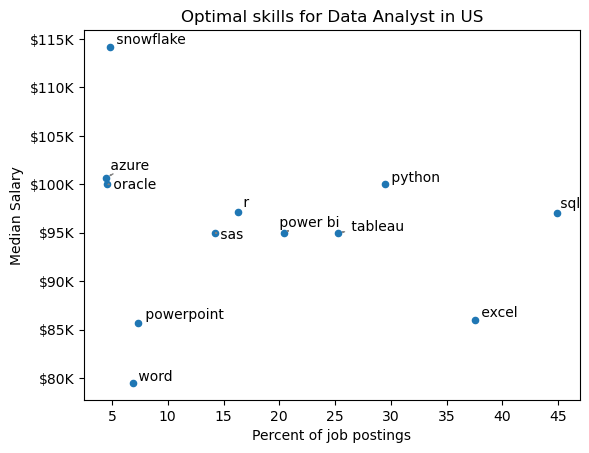

In [8]:
from adjustText import adjust_text

df_DA_skills_high_demand.plot(kind="scatter", x="skill_perc", y="median_salary")

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  

text = []

for i,txt in enumerate(df_DA_skills_high_demand.index):
    text.append(plt.text(df_DA_skills_high_demand["skill_perc"].iloc[i], df_DA_skills_high_demand["median_salary"].iloc[i], " " + txt))

adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel("Percent of job postings")
plt.ylabel("Median Salary")
plt.title("Optimal skills for Data Analyst in US")
plt.show()

### Bonus: Coloring by Technology
We're going to add color labels based on technology.

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [9]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['word',
  'alteryx',
  'power bi',
  'splunk',
  'powerbi',
  'dax',
  'qlik',
  'ms access',
  'spss',
  'cognos',
  'datarobot',
  'esquisse',
  'sharepoint',
  'sas',
  'spreadsheet',
  'ssis',
  'microstrategy',
  'visio',
  'excel',
  'sap',
  'ssrs',
  'powerpoint',
  'nuix',
  'outlook',
  'tableau',
  'sheets',
  'looker'],
 'async': ['confluence',
  'notion',
  'wrike',
  'airtable',
  'trello',
  'monday.com',
  'wimi',
  'workzone',
  'swit',
  'smartsheet',
  'clickup',
  'jira',
  'asana',
  'microsoft lists',
  'workfront',
  'dingtalk',
  'planner'],
 'cloud': ['databricks',
  'openstack',
  'vmware',
  'colocation',
  'watson',
  'ibm cloud',
  'aurora',
  'bigquery',
  'ovh',
  'digitalocean',
  'firebase',
  'heroku',
  'gcp',
  'redshift',
  'aws',
  'oracle',
  'azure',
  'snowflake',
  'linode'],
 'programming': ['solidity',
  'shell',
  'cobol',
  'haskell',
  'scala',
  'sql',
  'perl',
  'sass',
  'delphi',
  'php',
  'f#',
  'groovy',
  'kotl

In [10]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,word
0,analyst_tools,alteryx
0,analyst_tools,power bi
0,analyst_tools,splunk
0,analyst_tools,powerbi
...,...,...
9,sync,wire
9,sync,zoom
9,sync,ringcentral
9,sync,symphony


Merges two DataFrames, df_DA_skills and df_technology, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame df_DA_skills_tech.

In [11]:
# merge df_DA_skills and df_technology
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_perc,technology,skills
0,10704,97086.5000,44.918170,programming,sql
1,8950,86009.5125,37.557700,analyst_tools,excel
2,7029,100000.0000,29.496433,programming,python
3,6025,95000.0000,25.283256,analyst_tools,tableau
4,4858,95000.0000,20.386068,analyst_tools,power bi
...,...,...,...,...,...
197,1,67818.0000,0.004196,libraries,opencv
198,1,100000.0000,0.004196,libraries,chainer
199,1,161000.0000,0.004196,webframeworks,blazor
200,1,198500.0000,0.004196,programming,kotlin


In [14]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_perc'] > skill_perc_limit]
df_DA_skills_tech_high_demand

,skill_count,median_salary,skill_perc,technology,skills
0,10704,97086.5000,44.918170,programming,sql
1,8950,86009.5125,37.557700,analyst_tools,excel
2,7029,100000.0000,29.496433,programming,python
3,6025,95000.0000,25.283256,analyst_tools,tableau
4,4858,95000.0000,20.386068,analyst_tools,power bi
5,3888,97193.2500,16.315569,programming,r
6,3382,95000.0000,14.192195,analyst_tools,sas
7,3382,95000.0000,14.192195,programming,sas
8,1740,85687.5000,7.301721,analyst_tools,powerpoint
9,1635,79500.0000,6.861099,analyst_tools,word


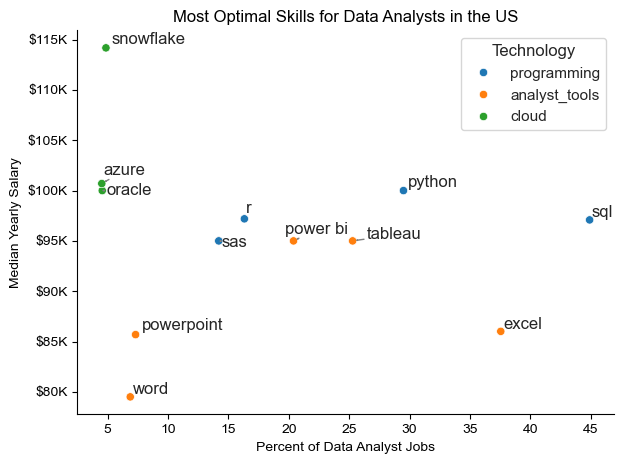

In [15]:
sns.scatterplot(data=df_DA_skills_tech_high_demand, x='skill_perc', y='median_salary', hue='technology')

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_perc'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))


# Adjust layout and display plot 
plt.tight_layout()
plt.show()